In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

# Exploratory Data Analysis

## Stage 5: Numeric Distribution Analysis

This stage analyzes the distributions of continuous numeric features.

The analysis includes histograms, kernel density estimation, mean,
median, skewness, and excess kurtosis.

Suspicious zero values in resting blood pressure and cholesterol are
temporarily treated as missing values for exploratory analysis only.
The original dataset remains unchanged.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print("Current directory:")
print(CURRENT_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nData path:")
print(DATA_PATH)

print("\nData file exists:")
print(DATA_PATH.exists())

Current directory:
E:\Projects\DataMining\notebooks

Project root:
E:\Projects\DataMining

Data path:
E:\Projects\DataMining\data\raw\data.csv

Data file exists:
True


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The dataset file was not found.\n"
        f"Checked path: {DATA_PATH}"
    )


df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()


print("Dataset loaded successfully.")
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

Dataset loaded successfully.
Number of rows: 920
Number of columns: 16


In [4]:
df_eda = df_raw.copy(deep=True)


SUSPICIOUS_ZERO_FEATURES = [
    "trestbps",
    "chol",
]


eda_adjustment_rows = []


for feature in SUSPICIOUS_ZERO_FEATURES:
    zero_count = int(
        (df_eda[feature] == 0).sum()
    )

    original_missing_count = int(
        df_eda[feature].isna().sum()
    )

    df_eda[feature] = df_eda[feature].replace(
        0,
        np.nan,
    )

    adjusted_missing_count = int(
        df_eda[feature].isna().sum()
    )

    eda_adjustment_rows.append(
        {
            "feature": feature,
            "zero_values_replaced": zero_count,
            "original_missing_count": original_missing_count,
            "adjusted_missing_count": adjusted_missing_count,
        }
    )


eda_adjustment_report = pd.DataFrame(
    eda_adjustment_rows
)


display(eda_adjustment_report)

,feature,zero_values_replaced,original_missing_count,adjusted_missing_count
0,trestbps,1,59,60
1,chol,172,30,202


In [5]:
CONTINUOUS_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
]


missing_features = [
    feature
    for feature in CONTINUOUS_FEATURES
    if feature not in df_eda.columns
]


if missing_features:
    raise ValueError(
        f"Required features are missing: {missing_features}"
    )


print("Continuous features:")
print(CONTINUOUS_FEATURES)

print(f"\nNumber of continuous features: {len(CONTINUOUS_FEATURES)}")

Continuous features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Number of continuous features: 5


In [6]:
def classify_skewness(skewness_value):
    absolute_value = abs(skewness_value)

    if absolute_value < 0.5:
        return "approximately symmetric"

    if absolute_value < 1.0:
        if skewness_value > 0:
            return "moderately right-skewed"

        return "moderately left-skewed"

    if skewness_value > 0:
        return "highly right-skewed"

    return "highly left-skewed"


def classify_kurtosis(kurtosis_value):
    if kurtosis_value > 0.5:
        return "leptokurtic"

    if kurtosis_value < -0.5:
        return "platykurtic"

    return "approximately mesokurtic"

In [7]:
distribution_rows = []


for feature in CONTINUOUS_FEATURES:
    feature_values = (
        df_eda[feature]
        .dropna()
    )

    skewness_value = feature_values.skew()
    kurtosis_value = feature_values.kurt()

    distribution_rows.append(
        {
            "feature": feature,
            "available_count": int(
                feature_values.shape[0]
            ),
            "missing_count": int(
                df_eda[feature].isna().sum()
            ),
            "mean": feature_values.mean(),
            "median": feature_values.median(),
            "standard_deviation": feature_values.std(
                ddof=1
            ),
            "minimum": feature_values.min(),
            "maximum": feature_values.max(),
            "skewness": skewness_value,
            "skewness_classification": (
                classify_skewness(
                    skewness_value
                )
            ),
            "excess_kurtosis": kurtosis_value,
            "kurtosis_classification": (
                classify_kurtosis(
                    kurtosis_value
                )
            ),
        }
    )


distribution_statistics = pd.DataFrame(
    distribution_rows
)


display(distribution_statistics.round(3))

,feature,available_count,missing_count,mean,median,standard_deviation,minimum,maximum,skewness,skewness_classification,excess_kurtosis,kurtosis_classification
0,age,920,0,53.511,54.0,9.425,28.0,77.0,-0.196,approximately symmetric,-0.383,approximately mesokurtic
1,trestbps,860,60,132.286,130.0,18.536,80.0,200.0,0.630,moderately right-skewed,0.631,leptokurtic
2,chol,718,202,246.833,239.5,58.527,85.0,603.0,1.315,highly right-skewed,4.773,leptokurtic
3,thalch,865,55,137.546,140.0,25.926,60.0,202.0,-0.211,approximately symmetric,-0.480,approximately mesokurtic
4,oldpeak,858,62,0.879,0.5,1.091,-2.6,6.2,1.041,highly right-skewed,1.127,leptokurtic


In [8]:
skewness_ranking = distribution_statistics[
    [
        "feature",
        "skewness",
        "skewness_classification",
        "excess_kurtosis",
        "kurtosis_classification",
    ]
].copy()


skewness_ranking["absolute_skewness"] = (
    skewness_ranking["skewness"].abs()
)


skewness_ranking = skewness_ranking.sort_values(
    by="absolute_skewness",
    ascending=False,
).reset_index(drop=True)


display(skewness_ranking.round(3))

,feature,skewness,skewness_classification,excess_kurtosis,kurtosis_classification,absolute_skewness
0,chol,1.315,highly right-skewed,4.773,leptokurtic,1.315
1,oldpeak,1.041,highly right-skewed,1.127,leptokurtic,1.041
2,trestbps,0.630,moderately right-skewed,0.631,leptokurtic,0.630
3,thalch,-0.211,approximately symmetric,-0.480,approximately mesokurtic,0.211
4,age,-0.196,approximately symmetric,-0.383,approximately mesokurtic,0.196


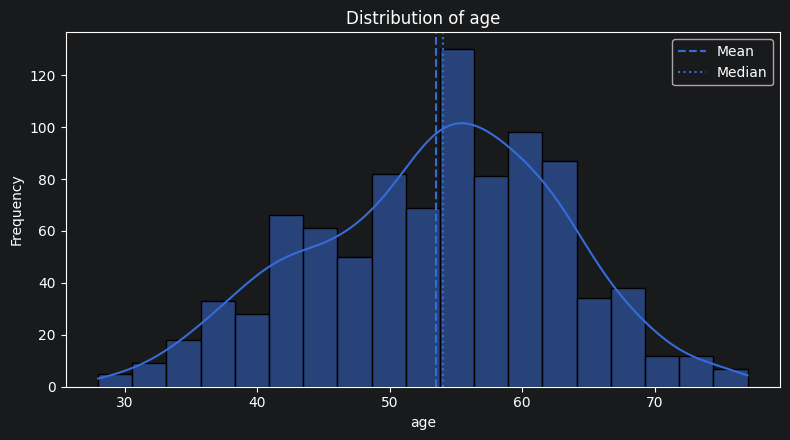

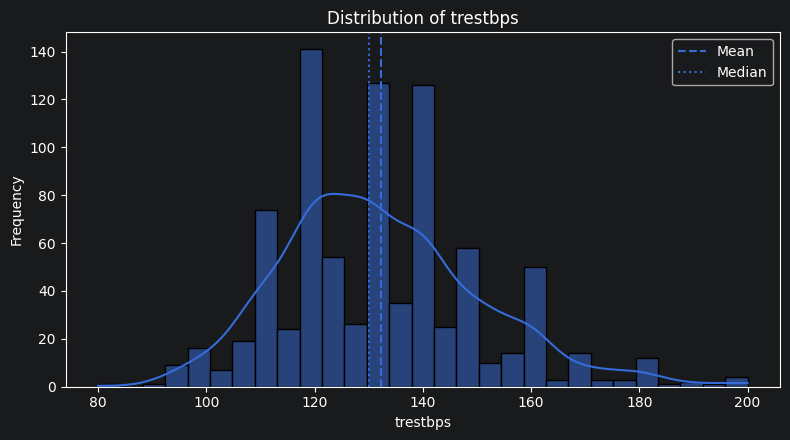

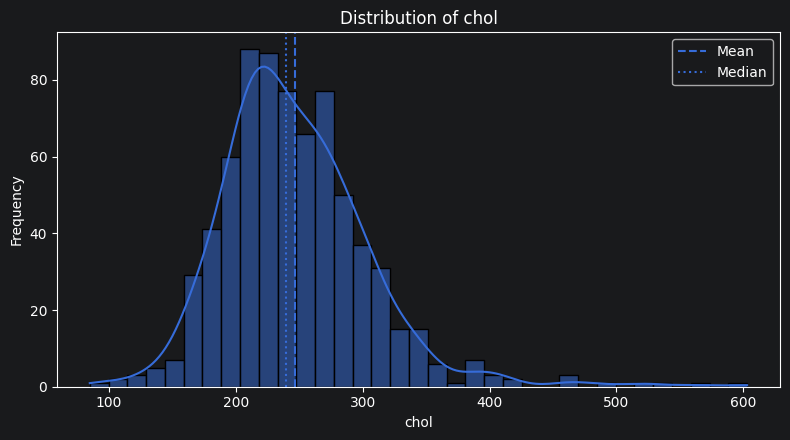

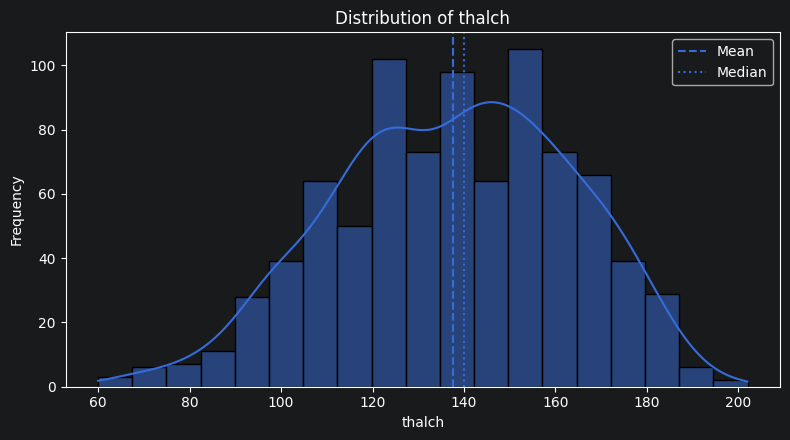

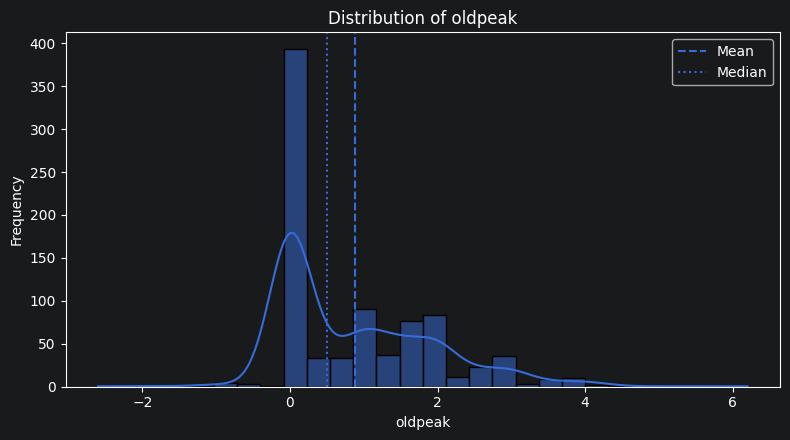

In [9]:
for feature in CONTINUOUS_FEATURES:
    feature_values = df_eda[feature].dropna()

    plt.figure(figsize=(8, 4.5))

    sns.histplot(
        feature_values,
        bins="auto",
        kde=True,
    )

    plt.axvline(
        feature_values.mean(),
        linestyle="--",
        linewidth=1.5,
        label="Mean",
    )

    plt.axvline(
        feature_values.median(),
        linestyle=":",
        linewidth=1.5,
        label="Median",
    )

    plt.title(
        f"Distribution of {feature}"
    )
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()

    figure_path = (
        FIGURES_DIR
        / f"05_histogram_kde_{feature}.png"
    )

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

In [10]:
transformation_candidates = (
    distribution_statistics[
        distribution_statistics["skewness"]
        .abs()
        >= 1.0
    ][
        [
            "feature",
            "minimum",
            "maximum",
            "skewness",
            "skewness_classification",
        ]
    ]
    .copy()
)


transformation_candidates[
    "contains_non_positive_values"
] = transformation_candidates[
    "feature"
].apply(
    lambda feature: (
        df_eda[feature].dropna() <= 0
    ).any()
)


display(transformation_candidates.round(3))

,feature,minimum,maximum,skewness,skewness_classification,contains_non_positive_values
2,chol,85.0,603.0,1.315,highly right-skewed,False
4,oldpeak,-2.6,6.2,1.041,highly right-skewed,True


In [11]:
distribution_statistics.to_csv(
    TABLES_DIR / "05_distribution_statistics.csv",
    index=False,
    encoding="utf-8-sig",
)

eda_adjustment_report.to_csv(
    TABLES_DIR / "05_eda_adjustment_report.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 5 tables saved successfully.")

print(
    TABLES_DIR
    / "05_distribution_statistics.csv"
)

print(
    TABLES_DIR
    / "05_eda_adjustment_report.csv"
)

Stage 5 tables saved successfully.
E:\Projects\DataMining\outputs\tables\05_distribution_statistics.csv
E:\Projects\DataMining\outputs\tables\05_eda_adjustment_report.csv


In [12]:
assert df_raw.shape == (920, 16), (
    "The original dataset shape changed unexpectedly."
)

assert int(
    (df_raw["trestbps"] == 0).sum()
) == 1, (
    "The original trestbps values changed unexpectedly."
)

assert int(
    (df_raw["chol"] == 0).sum()
) == 172, (
    "The original chol values changed unexpectedly."
)

assert int(
    df_eda["trestbps"].isna().sum()
) == 60, (
    "The adjusted trestbps missing count is incorrect."
)

assert int(
    df_eda["chol"].isna().sum()
) == 202, (
    "The adjusted chol missing count is incorrect."
)

assert len(distribution_statistics) == 5, (
    "The distribution table must contain five features."
)

assert (
    distribution_statistics["skewness"]
    .notna()
    .all()
), (
    "Skewness values must not be missing."
)

assert (
    distribution_statistics[
        "excess_kurtosis"
    ]
    .notna()
    .all()
), (
    "Kurtosis values must not be missing."
)


required_output_files = [
    TABLES_DIR
    / "05_distribution_statistics.csv",
    TABLES_DIR
    / "05_eda_adjustment_report.csv",
]


for feature in CONTINUOUS_FEATURES:
    required_output_files.append(
        FIGURES_DIR
        / f"05_histogram_kde_{feature}.png"
    )


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 5 validation checks passed.")

All Stage 5 validation checks passed.
